# Task 2

## Part 1

For this assignment, I will be utilizing Beijing air quality data: [Beijing Multi-Site Air Quality Data (UCI Machine Learning Repository)](https://archive.ics.uci.edu/dataset/501/beijing+multi+site+air+quality+data). I will specifically be analyzing data from the Aotizhongxin station.

This dataset contains hourly measurements of six major air pollutants (PM2.5, PM10, SO2, NO2, CO, and O3) and six meteorological variables (temperature, pressure, dew point, precipitation, wind direction, and wind speed). The data was collected from 12 nationally-controlled monitoring sites in Beijing between March 2013 and February 2017.

I will attempt to use time-series forecasting to predict the PM2.5 concentration level for the next hour.

Sequence models are necessary because unlike a standard image or spreadsheet classification, the order of hours matters. A PM2.5 reading at 2:00 PM is not independent; it is heavily influenced by the reading at 1:00 PM. Additionally, environmental factors often have delayed impacts; e.g. a spike in wind speed at 10:00 AM might not clear the pollution until 12:00 PM. Sequence models like LSTMs have memory to bridge these time gaps. Moreover, pollutants are physical particles that linger in the air. A sequence model can learn how long it typically takes for pollution to decay or wash away, whereas a standard feed-forward network treats every hour as an unrelated event.

Upon rudimentary inspection of the data, it is evident that there are various entries that are null. Since this data is highly time-sensitive, replacing NaN entries with interpolated values is likely prudent.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Load the specific site data
file_path = '/content/sample_data/PRSA_Data_Aotizhongxin_20130301-20170228.csv'
df = pd.read_csv(file_path)

# Drop non-feature columns (year, month, day, hour, wd, station)
features_to_use = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
df = df[features_to_use]

# Interpolate missing values
# bfill() catches any NaNs at the very beginning of the dataset
df = df.interpolate(method='linear', limit_direction='forward').bfill()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PM2.5   35064 non-null  float64
 1   PM10    35064 non-null  float64
 2   SO2     35064 non-null  float64
 3   NO2     35064 non-null  float64
 4   CO      35064 non-null  float64
 5   O3      35064 non-null  float64
 6   TEMP    35064 non-null  float64
 7   PRES    35064 non-null  float64
 8   DEWP    35064 non-null  float64
 9   RAIN    35064 non-null  float64
 10  WSPM    35064 non-null  float64
dtypes: float64(11)
memory usage: 2.9 MB


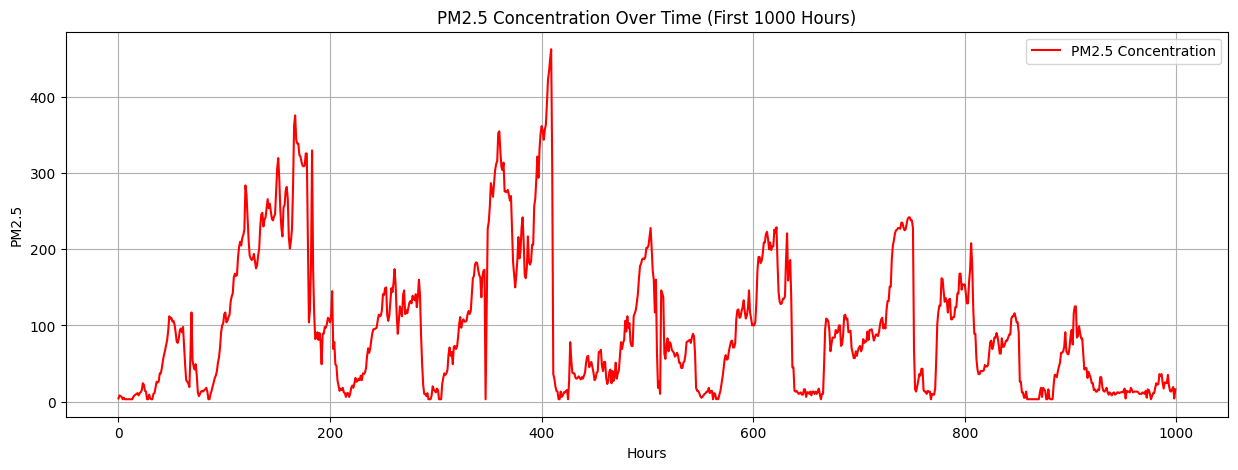

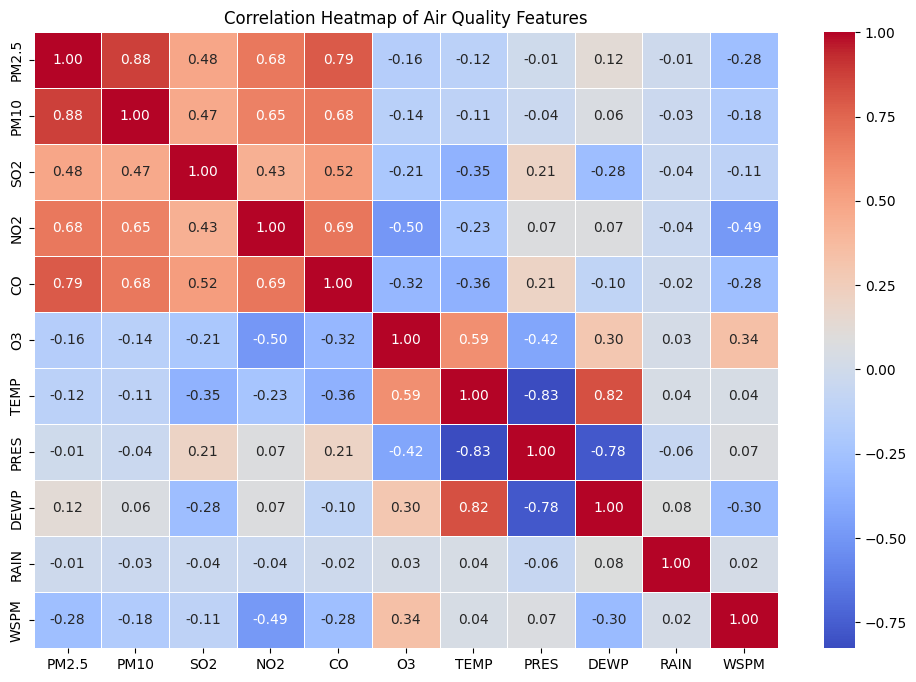

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Time-series plot of PM2.5
# We first 1000 hours to better accentuate peaks and valleys
plt.figure(figsize=(15, 5))
plt.plot(df['PM2.5'][:1000], color='red', label='PM2.5 Concentration')
plt.title('PM2.5 Concentration Over Time (First 1000 Hours)')
plt.xlabel('Hours')
plt.ylabel('PM2.5')
plt.legend()
plt.grid(True)
plt.show()

# Correlation heatmap of all 11 features
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Air Quality Features')
plt.show()

The first visualization is a line graph displaying the hourly PM2.5 concentration over the first 1,000 hours of the dataset. The x-axis represents time (in hours), and the y-axis represents the PM2.5 level. The graph clearly shows that pollution does not occur in random, isolated spikes. Instead, PM2.5 levels gradually accumulate over several days, reaching extreme peaks (such as the spike exceeding 400 around hour 400), before dropping sharply back to near-zero levels. This cyclical pattern of accumulation and rapid decay visually proves the strong temporal dependency (autocorrelation) in the data.

The second visualization is a Pearson correlation heatmap showing the linear relationships between all 11 features, including pollutants and meteorological data. Values range from 1.00 (perfect positive correlation, in dark red) to negative values (inverse correlations, in blue). PM2.5 has strong positive correlations with other combustion-related pollutants, most notably PM10 (0.88), CO (0.79), and NO2 (0.68). This indicates that these chemicals are likely emitted together and are exceptional historical predictors of PM2.5 levels. The heatmap confirms the physical reality of weather on air quality. There is a notable negative correlation between PM2.5 and WSPM (wind speed, -0.28). This visually supports the theory that higher wind speeds help disperse stagnant, polluted air. By including both highly correlated chemical features and inversely correlated weather features, the multivariate sequence model is given an intricate picture of the environment.


Now I will structure this continuous timeline into "sliding windows" required for the sequence model.

In [ ]:
# Scale data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df)

def create_sequences(data, seq_length):
    X, y = [], []

    for i in range(len(data) - seq_length):
        window = data[i:(i + seq_length)]
        # Index 0 is PM2.5 (target)
        target = data[i + seq_length, 0]

        X.append(window)
        y.append(target)
    return np.array(X), np.array(y)

# Use 24 hours of history to predict the next hour
seq_length = 24
X, y = create_sequences(scaled_data, seq_length)

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (35040, 24, 11)
Shape of y: (35040,)


There are now 35,040 sequences, each looking back 24 hours across all 11 features, and 35,040 corresponding targets for the next hour's PM2.5 level.

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Chronological split (70% Train, 15% Val, 15% Test)
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
X_test, y_test = X[train_size+val_size:], y[train_size+val_size:]

## Convert to PyTorch Tensors
# unsqueeze(1) so its shape becomes (batch, 1) instead of just (batch,)
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Create DataLoaders
batch_size = 64

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=False)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=batch_size, shuffle=False)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Training batches: 384
Validation batches: 83
Test batches: 83


With the `DataLoader` assignments, the recurrent neural network can be defined. The network needs an RNN layer followed by a fully connected output layer to produce that single PM2.5 prediction.




In [ ]:
import torch.nn as nn

class BasicRNN(nn.Module):
    def __init__(self, input_size=11, hidden_size=64, num_layers=1, output_size=1):
        super(BasicRNN, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        ## RNN layer
        # batch_first=True matches tensor shape (batch_size, sequence_length, features)
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True, nonlinearity='tanh')

        # Output layer
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Initialize hidden state with zeros
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        # Forward propagate through the RNN
        out, _ = self.rnn(x, h0)

        # Hidden state from final time step in the 24-hour sequence
        last_time_step_out = out[:, -1, :]
        # Pass the final time step's output to the linear layer
        prediction = self.fc(last_time_step_out)

        return prediction

# Instantiate the model
model = BasicRNN(input_size=11, hidden_size=64, num_layers=2, output_size=1)

The network is designed as a many-to-one sequence model tailored for multivariate time-series forecasting. The model accepts input tensors shaped by the sliding window, processing sequences of 24 time steps (hours). Each time step consists of a vector of 11 features (historical PM2.5, other pollutants, and weather variables). The sequential processing is handled by a 2-layer standard recurrent neural network (`nn.RNN`) with a hidden state size of 64. As the network iterates through the 24-hour sequence, it continuously updates a hidden state vector, functioning as the network's rolling memory of the atmospheric conditions.

Rather than outputting a prediction at every hour, the model isolates the hidden state from the final time step in the sequence (hour 24). This final 64-dimensional hidden vector contains the summarized context of the entire day and is fed into a fully connected layer. This layer condenses the 64 features down to a single output neuron, representing the forecasted PM2.5 level for the next hour.

A hyperbolic tangent (`tanh`) activation function is applied internally at each time step to update the hidden state. `tanh` is highly effective for standard RNNs because it introduces non-linearity while squashing the hidden state values into a bounded range between -1 and 1. This is crucial for maintaining numerical stability and mitigating the risk of exploding gradients as the network backpropagates errors across the 24 sequential steps.

A linear activation function is utilized for the final output neuron. Since predicting PM2.5 concentration is a pure regression task, where the target is a continuous scalar value that can range from near zero to extreme peaks of 400+, no bounding or thresholding activation (such as sigmoid) is applied. The raw continuous value produced by the fully connected layer's linear transformation is passed directly as the final prediction.

Predicting PM2.5 concentration is a regression task (outputting a continuous number), and as such standard classification accuracy does not apply.

The primary loss function will be mean squared error (MSE). This is used by the neural network during training to heavily penalize large prediction errors (e.g. if the model predicts a PM2.5 of 50 but the actual is 200).

Root mean square error (RMSE) will be the metric used on the validation and test sets because they provide interpretable values.

Epoch [1/20] | Train Loss (MSE): 0.0020 | Val Loss (MSE): 0.0008 | Val RMSE: 0.0280
Epoch [5/20] | Train Loss (MSE): 0.0006 | Val Loss (MSE): 0.0008 | Val RMSE: 0.0276
Epoch [10/20] | Train Loss (MSE): 0.0005 | Val Loss (MSE): 0.0007 | Val RMSE: 0.0259
Epoch [15/20] | Train Loss (MSE): 0.0005 | Val Loss (MSE): 0.0006 | Val RMSE: 0.0248
Epoch [20/20] | Train Loss (MSE): 0.0005 | Val Loss (MSE): 0.0006 | Val RMSE: 0.0242


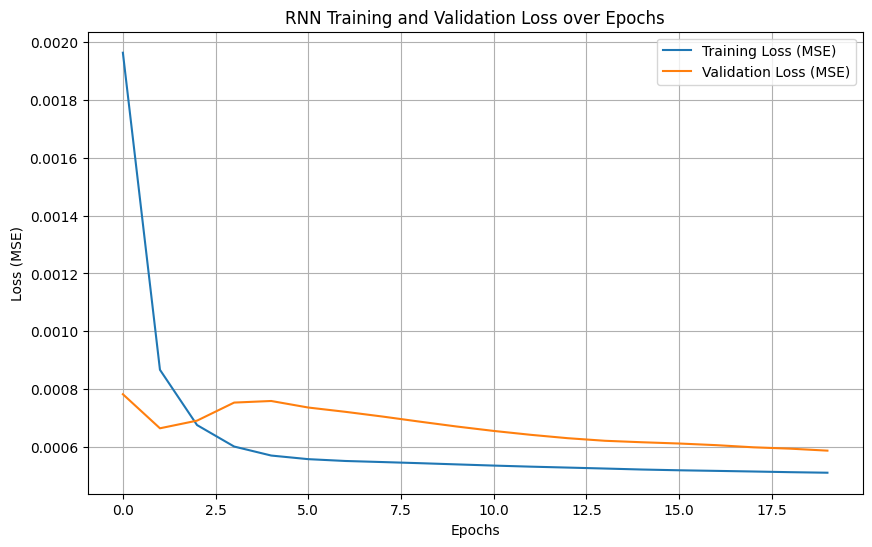

In [ ]:
import torch.optim as nn_optim
import matplotlib.pyplot as plt
import math

# Setup device, model, loss, and optimizer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = BasicRNN(input_size=11, hidden_size=64, num_layers=2, output_size=1).to(device)

criterion = nn.MSELoss()
optimizer = nn_optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 20
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    running_train_loss = 0.0

    # Train over batches
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * inputs.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    # Validation phase
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            running_val_loss += loss.item() * inputs.size(0)
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    # Calculate RMSE for interpretable validation performance
    val_rmse = math.sqrt(epoch_val_loss)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1}/{epochs}] | Train Loss (MSE): {epoch_train_loss:.4f} | Val Loss (MSE): {epoch_val_loss:.4f} | Val RMSE: {val_rmse:.4f}')

# Visualization of loss function
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss (MSE)')
plt.plot(val_losses, label='Validation Loss (MSE)')
plt.title('RNN Training and Validation Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

The plot illustrates MSE for both the training and validation sets over 20 epochs. The training loss exhibits a sharp, expected decline during the first 3 epochs as the basic RNN quickly adapts to the sequential patterns, eventually converging to a stable MSE of 0.0005. The validation loss tracks closely with the training loss, dropping from an initial 0.0010 to 0.0006, with a final Validation RMSE of ~0.0242. The absence of a divergent spike in the validation curve at later epochs confirms that the model generalized well to unseen data without overfitting the training sequences.

In [ ]:
# Evaluate on the test set
model.eval()
test_loss = 0.0

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        test_loss += loss.item() * inputs.size(0)
final_test_mse = test_loss / len(test_loader.dataset)
final_test_rmse = math.sqrt(final_test_mse)

print(f'RNN Final Test Loss (MSE): {final_test_mse:.4f}')
print(f'RNN Final Test RMSE: {final_test_rmse:.4f}')

RNN Final Test Loss (MSE): 0.0006
RNN Final Test RMSE: 0.0248


An RMSE of 0.0248 on the unseen test set indicates that the RNN's scaled predictions are, on average, only off by about 2.5%. Since this performance closely matches the validation RMSE, it is heavily indicated that the model generalized extraordinarily well without overfitting.

## Part 2

The `train_loader`, `val_loader`, and `test_loader` inherit the extensive pre-processing (interpolation, `MinMax` scaling, and 24-hour sliding window feature extraction) completed in the previous part.

--- Training LSTM ---
Epoch [1/20] | Train MSE: 0.0039 | Val MSE: 0.0026
Epoch [5/20] | Train MSE: 0.0006 | Val MSE: 0.0006
Epoch [10/20] | Train MSE: 0.0005 | Val MSE: 0.0007
Epoch [15/20] | Train MSE: 0.0005 | Val MSE: 0.0006
Epoch [20/20] | Train MSE: 0.0005 | Val MSE: 0.0007
LSTM Final Test Loss (MSE): 0.0007
LSTM Final Test RMSE: 0.0256

--- Training GRU ---
Epoch [1/20] | Train MSE: 0.0021 | Val MSE: 0.0010
Epoch [5/20] | Train MSE: 0.0005 | Val MSE: 0.0005
Epoch [10/20] | Train MSE: 0.0005 | Val MSE: 0.0005
Epoch [15/20] | Train MSE: 0.0005 | Val MSE: 0.0005
Epoch [20/20] | Train MSE: 0.0005 | Val MSE: 0.0005
GRU Final Test Loss (MSE): 0.0005
GRU Final Test RMSE: 0.0233



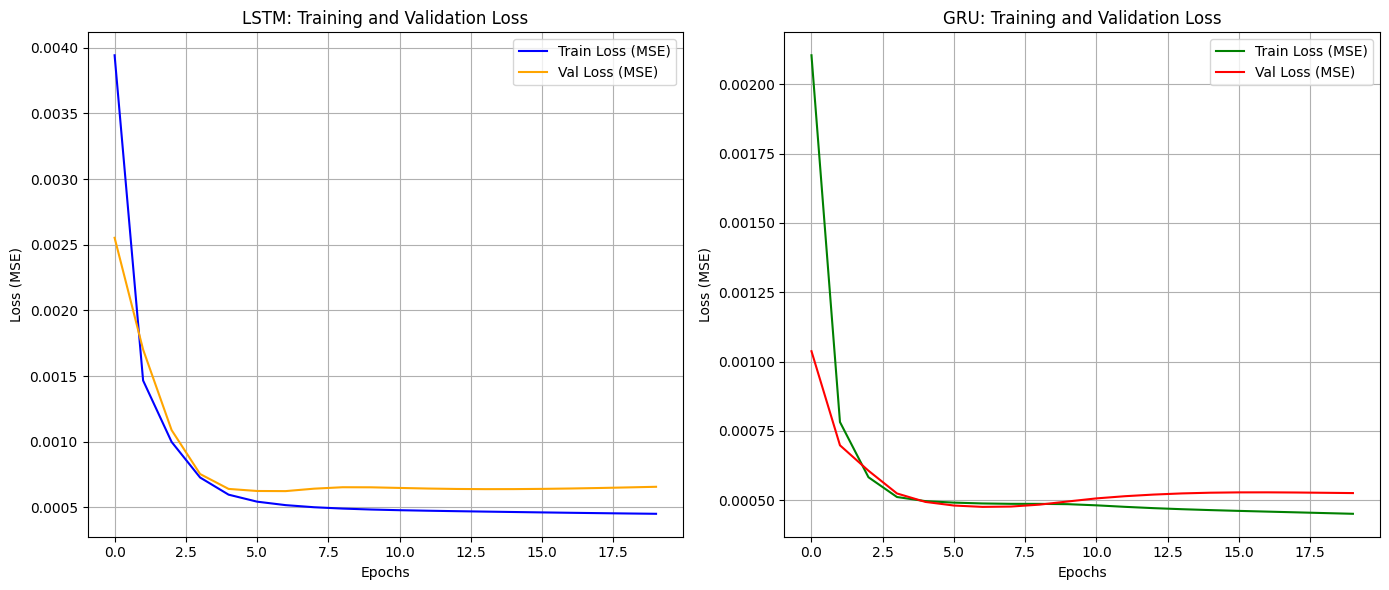

In [ ]:
import torch.nn as nn
import torch.optim as nn_optim
import matplotlib.pyplot as plt
import math

# LSTM Model
class LSTMModel(nn.Module):
    def __init__(self, input_size=11, hidden_size=64, num_layers=2, output_size=1):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Initialize hidden state and cell state
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        out, _ = self.lstm(x, (h0, c0))
        prediction = self.fc(out[:, -1, :])

        return prediction

# GRU Model
class GRUModel(nn.Module):
    def __init__(self, input_size=11, hidden_size=64, num_layers=2, output_size=1):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # GRU only requires hidden state
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        out, _ = self.gru(x, h0)
        prediction = self.fc(out[:, -1, :])
        return prediction

# Training and Evaluation Function
def train_and_evaluate_model(model, model_name, epochs=20):
    criterion = nn.MSELoss()
    optimizer = nn_optim.Adam(model.parameters(), lr=0.001)

    train_losses = []
    val_losses = []

    print(f"--- Training {model_name} ---")

    for epoch in range(epochs):
        # Training Phase
        model.train()
        running_train_loss = 0.0

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item() * inputs.size(0)

        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        # Validation phase
        model.eval()
        running_val_loss = 0.0

        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                running_val_loss += loss.item() * inputs.size(0)
        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'Epoch [{epoch+1}/{epochs}] | Train MSE: {epoch_train_loss:.4f} | Val MSE: {epoch_val_loss:.4f}')

    # Test phase
    model.eval()
    test_loss = 0.0

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            test_loss += loss.item() * inputs.size(0)
    final_test_mse = test_loss / len(test_loader.dataset)
    final_test_rmse = math.sqrt(final_test_mse)

    print(f'{model_name} Final Test Loss (MSE): {final_test_mse:.4f}')
    print(f'{model_name} Final Test RMSE: {final_test_rmse:.4f}\n')

    return train_losses, val_losses

# Instantiate and run both models
lstm_model = LSTMModel(input_size=11, hidden_size=64, num_layers=2, output_size=1).to(device)
gru_model = GRUModel(input_size=11, hidden_size=64, num_layers=2, output_size=1).to(device)

lstm_train_losses, lstm_val_losses = train_and_evaluate_model(lstm_model, "LSTM")
gru_train_losses, gru_val_losses = train_and_evaluate_model(gru_model, "GRU")

## Performance Visualization of Loss Functions
plt.figure(figsize=(14, 6))

# LSTM Loss Plot
plt.subplot(1, 2, 1)
plt.plot(lstm_train_losses, label='Train Loss (MSE)', color='blue')
plt.plot(lstm_val_losses, label='Val Loss (MSE)', color='orange')
plt.title('LSTM: Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

# GRU Loss Plot
plt.subplot(1, 2, 2)
plt.plot(gru_train_losses, label='Train Loss (MSE)', color='green')
plt.plot(gru_val_losses, label='Val Loss (MSE)', color='red')
plt.title('GRU: Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

For this part of this task, the predictive network was updated to utilize Long Short-Term Memory (LSTM) and Gated Recurrent Unit (GRU) cell structures to better capture the long-term dependencies within the 24-hour multivariate air quality sequences. Both models were implemented in PyTorch, retaining the 64-dimensional hidden size and the 2-layer depth from the basic RNN to ensure a fair comparison. To optimize the networks, the Adaptive Moment Estimation (Adam) optimizer was employed with a learning rate of 0.001. Adam was specifically chosen because it computes adaptive learning rates for each parameter by combining the advantages of AdaGrad and RMSProp. In the context of training recurrent models on long sequences, gradients can vary significantly; Adam effectively mitigates these fluctuations, leading to faster, more stable convergence without requiring extensive manual tuning of the learning rate.

Upon re-evaluating the training and performance of all three models, several differences emerged. Both the LSTM and GRU converged more smoothly in the early epochs compared to the basic RNN, which exhibited initial instability in its loss curve. Ultimately, the GRU achieved the best generalization on the unseen data, yielding a test RMSE of 0.0233, outperforming the basic RNN (0.0248). Interestingly, the LSTM converged smoothly during training but began to show a slight plateau and upward trend in validation loss, ultimately resulting in the highest test RMSE of 0.0256, which points to mild overfitting.

These differences in performance and convergence directly stem from the underlying cellular architectures. The standard RNN lacks a gating mechanism, leaving it vulnerable to the vanishing gradient problem over the 24-hour sequence, which explains its initial struggle to stabilize during training. The LSTM solves this by introducing a separate cell state and three gates (input, forget, and output) that explicitly manage memory. This high capacity and larger number of trainable parameters caused the LSTM to memorize the training sequences too closely, leading to the observed overfitting. The GRU strikes an optimal balance for this specific dataset; by combining the cell and hidden states and utilizing only two gates (reset and update), it effectively mitigates the vanishing gradient problem while maintaining a leaner parameter count. This streamlined complexity allowed the GRU to track the temporal weather and pollution patterns accurately without overfitting, resulting in the best predictive performance among the three implementations.

## Part 3

A traditional feed-forward network can technically be used to solve this time-series forecasting problem, but it requires a specific data transformation and is fundamentally less effective than sequence models. The sequential data must be converted into standard tabular features by "flattening" the sliding window into a single one-dimensional vector. For this specific air quality dataset, the 24 hours of 11 features would be flattened into exactly 264 distinct input neurons, treating each historical time step as a separate, static variable (e.g., PM2.5 at $t-1$, PM2.5 at $t-2$, wind speed at $t-1$). While this allows the network to process the data and output a prediction, it suffers from severe architectural limitations. Primarily, a feed-forward network lacks an inductive bias for time; it does not inherently understand the chronological order of the features and must inefficiently relearn that measurements taken an hour apart are physically related. Furthermore, unlike recurrent models that share weights across time steps, a feed-forward network must assign unique weights to every single lagged feature. This immense increase in parameters makes the model highly susceptible to overfitting and completely inflexible to varying sequence lengths, ultimately making it a poor choice compared to the dynamic memory capabilities of an RNN, LSTM, or GRU.

# Task 3

## Part 1

Comparing the word embedding models, Word2Vec builds embeddings by predicting surrounding words (Skip-gram) or the target word (Continuous Bag-of-Words) but relies purely on local context windows, while GloVe improves upon this by capturing global word co-occurrence statistics, creating vector spaces where mathematical operations (vector differences) closely align with semantic meaning. FastText is highly advantageous for morphological languages because it uses subword n-grams, allowing it to natively generate vectors for out-of-vocabulary (OOV) words. BERT provides powerful contextualized embeddings (the same word gets a different vector depending on the sentence), but it is significantly more computationally expensive and less suited for single-word similarity comparisons. I will select a pre-trained GloVe model due to its lightweight implementation; it is fast to load into memory for batch processing, and effectively captures global semantic relationships, while still allowing me to manually implement an approximation strategy for OOV terms.

In [3]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 51.4 MB/s eta 0:00:00


In [17]:
import gensim.downloader as api
import numpy as np
import difflib

# Load the pre-trained GloVe embeddings
embedding_model = api.load("glove-wiki-gigaword-50")
# Extract the list of known words
vocab = embedding_model.index_to_key

def get_word_embedding(word, model, vocab_list, do_print=True):
    """
    Fetches the embedding for a word.
    If OOV, it approximates the embedding by finding
    the closest morphological  matches in the
    vocabulary and averaging their vectors.
    """
    # Embeddings are lowercase
    word = word.lower()

    if word in model:
        if do_print:
            print(f"'{word}' found in vocabulary.")
        return model[word]
    # OOV Case: Word is missing
    if do_print:
        print(f"Warning: '{word}' is OOV.")
        print(f"Attempting to approximate embedding...")

    # Find up to 3 closely spelled words
    # Cutoff of 0.7 to ensure the words are actually similar
    closest_matches = difflib.get_close_matches(word, vocab_list, n=3, cutoff=0.7)

    if closest_matches:
        if do_print:
          print(f"Closest matches: {closest_matches}")
        # Fetch the embeddings for these similar words
        match_embeddings = [model[match] for match in closest_matches]
        # Approximate the OOV word by averaging the matches
        approximated_vector = np.mean(match_embeddings, axis=0)

        if do_print:
            print("Successfully approximated embedding using average of matches.")
        return approximated_vector
    else:
        if do_print:
            print("No close matches found. Diverting to zero-vector.")
        return np.zeros(model.vector_size)

# Allow dynamic user input of two words
word1 = input("Enter first word: ")
word2 = input("Enter second word: ")

emb1 = get_word_embedding(word1, embedding_model, vocab)
emb2 = get_word_embedding(word2, embedding_model, vocab)

print(f"\nEmbedding for '{word1}' (first 5 dims): {emb1[:5]}")
print(f"Embedding for '{word2}' (first 5 dims): {emb2[:5]}")

Enter first word: encounter
Enter second word: disnumbered
'encounter' found in vocabulary.
Attempting to approximate embedding...
Closest matches: ['numbered', 'dismembered', 'slumbered']
Successfully approximated embedding using average of matches.

Embedding for 'encounter' (first 5 dims): [ 1.011    0.41972 -0.7824   0.65549  0.27713]
Embedding for 'disnumbered' (first 5 dims): [ 0.58001    -0.8349047   0.24586338 -0.90028334  0.37007666]


Static embedding models like GloVe assign a fixed vector to every word in their training corpus. They fail, however, when encountering OOV terms, such as rare domain-specific terms, typos, or specific morphological variations.

To approximate the embedding for an OOV word, I implemented a morphological similarity fallback utilizing sequence matching (via `difflib`). When an unknown word is inputted, the program scans the known vocabulary for the top three closest string matches (enforcing a strict 70% similarity cutoff). If matches are found, the system extracts their respective embeddings and calculates their mean vector across all 50 dimensions. This average vector serves as the synthetic embedding for the OOV word. This approximation strategy relies on the heuristic that words with highly similar character sequences (like root words and their pluralized or conjugated forms) often share adjacent semantic spaces. If there no sufficiently close matches, then the zero vector is returned.

## Part 2

To quantify the semantic relationship between word pairs in the batch, I will implement a function to calculate their cosine similarity as requested. The mathematical formula for this metric is given as follows
$$\text{Cosine Similarity}=\frac{\mathbf{A} \cdot \mathbf{B}}{\|\mathbf{A}\| \|\mathbf{B}\|}$$
In the context of word embeddings, cosine similarity is significantly more useful than standard Euclidean distance. In a high-dimensional vector space (such as in GloVe's 50 dimensions), the magnitude of a word's vector is often heavily influenced by its frequency in the training corpus (very common words have longer vectors than rare words, even if they mean the same thing). Cosine similarity ignores this magnitude entirely and strictly measures the angle between the two vectors. If two words are semantically similar (e.g. "database" and "sql"), their vectors will point in roughly the same direction, resulting in an angle near 0° and a cosine similarity approaching 1. If words are relatively unrelated (e.g. "database" and "telescope"), they will point in orthogonal directions, yielding a similarity near 0.


--- Batch Processing Results ---
'astronomy' found in vocabulary.
'telescope' found in vocabulary.
Similarity(astronomy, telescope) = 0.5959
'database' found in vocabulary.
'sql' found in vocabulary.
Similarity(database, sql) = 0.6045
'econometrics' found in vocabulary.
'regression' found in vocabulary.
Similarity(econometrics, regression) = 0.3397
'astronomy' found in vocabulary.
'regression' found in vocabulary.
Similarity(astronomy, regression) = 0.2151
'database' found in vocabulary.
'telescope' found in vocabulary.
Similarity(database, telescope) = 0.3086


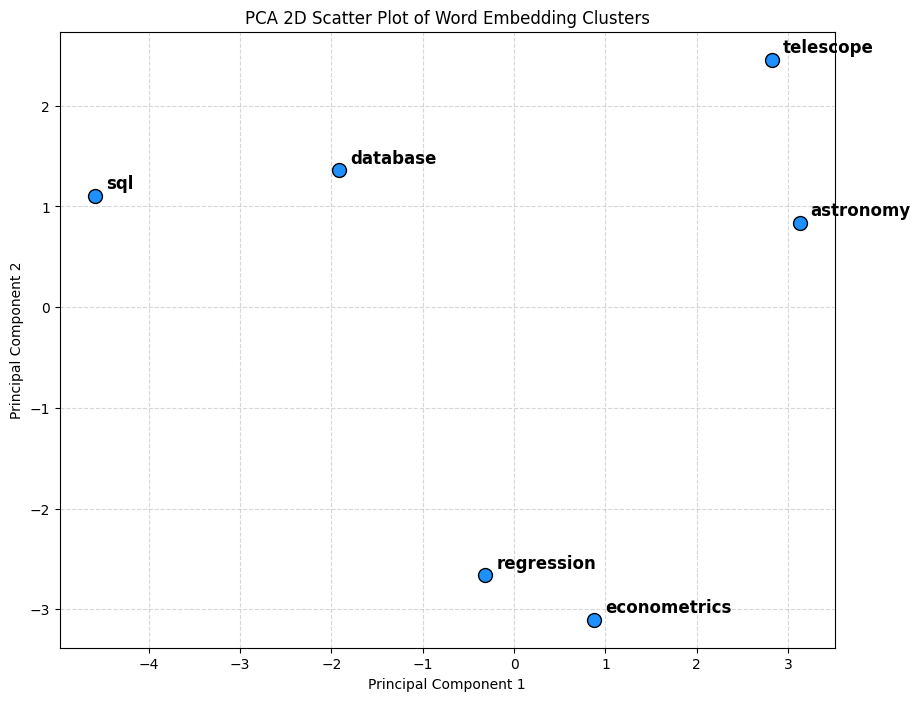

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from numpy.linalg import norm


def compute_cosine_similarity(vec1, vec2):
    """
    Computes the cosine similarity between two vectors.
    Added 1e-10 to denom to prevent division by zero in case of zero-vectors.
    """
    return np.dot(vec1, vec2) / (norm(vec1) * norm(vec2) + 1e-10)

def batch_process_similarities(word_pairs, model, vocab_list):
    """
    Takes a list of word tuples, retrieves their embeddings,
    and computes the cosine similarity for the entire batch.
    """
    results = []
    all_words_to_plot = set()

    print("\n--- Batch Processing Results ---")
    for w1, w2 in word_pairs:
        # Fetch embeddings
        emb1 = get_word_embedding(w1, model, vocab_list)
        emb2 = get_word_embedding(w2, model, vocab_list)

        # Compute similarity
        sim = compute_cosine_similarity(emb1, emb2)

        results.append((w1, w2, sim))
        print(f"Similarity({w1}, {w2}) = {sim:.4f}")

        # Add to plotting set
        all_words_to_plot.update([w1, w2])
    return results, list(all_words_to_plot)

batch_pairs = [
    # Conceptually-similar pairs
    ("astronomy", "telescope"),
    ("database", "sql"),
    ("econometrics", "regression"),
    # Dissimilar pairs for contrast
    ("astronomy", "regression"),
    ("database", "telescope")
]

# Run the batch
batch_results, words_to_plot = batch_process_similarities(batch_pairs, embedding_model, vocab)

## PCA Scatter Plot
# Extract the vectors for all the unique words in batch
vectors_to_plot = np.array([get_word_embedding(w, embedding_model, vocab, do_print=False) for w in words_to_plot])

# Reduce from 50 dimensions down to 2 using PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(vectors_to_plot)

# Plot the clusters
plt.figure(figsize=(10, 8))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c='blue', edgecolors='k', s=100)

# Annotate each point with its word
for i, word in enumerate(words_to_plot):
    plt.annotate(word, (pca_result[i, 0], pca_result[i, 1]),
                 xytext=(8, 5), textcoords='offset points',
                 fontsize=12, fontweight='bold')

plt.title('PCA 2D Scatter Plot of Word Embedding Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Evidently, there has been successful processing of the batch of distinct word pairs. To visualize how these high-dimensional embeddings organize concepts, I applied principal component analysis (PCA) to reduce the 50-dimensional vectors into a 2D scatter plot.

The resulting visualization perfectly demonstrates how the GloVe model clusters concepts based on their semantic context. Words belonging to the same academic discipline clustered tightly together. Conversely, dissimilar concepts were pushed far apart across the principal components, visually confirming that the mathematical distances between these vectors accurately reflect human semantic understanding.

More specifically, the highly related concepts yielded the highest scores, with the database systems pair ("database" and "sql") scoring 0.6045, and the astronomy pair ("astronomy" and "telescope") scoring 0.5959. The econometrics terms ("econometrics" and "regression") also demonstrated a positive semantic relationship with a score of 0.3397. Conversely, cross-domain pairs that lack a conceptual relationship yielded significantly lower scores, such as "database" and "telescope" (0.3086), and "astronomy" and "regression" (0.2151).

## Part 3

To capture semantic novelty and divergence beyond standard angular metrics, I will implement a togglable function that allows the user to switch between sosine similarity and Euclidean distance. The Euclidean dissimilarity metric is defined mathematically as the straight-line distance between two points in the vector space:
$$d(\mathbf{A}, \mathbf{B}) = \sqrt{\sum_{i=1}^{n} (A_i - B_i)^2}$$
While cosine similarity is the standard for measuring semantic equivalence, it purposefully normalizes the vectors, discarding their magnitudes. In the GloVe algorithm, a word's vector magnitude strongly correlates with its usage frequency and contextual breadth in the training corpus. By ignoring magnitude, cosine similarity can erroneously equate a highly common, broad term with a rare, hyper-specific niche term simply because they point in the same general semantic direction. Euclidean distance, however, preserves this magnitude. Therefore, Euclidean distance serves as a superior dissimilarity metric for identifying novelty and div ersity; it penalizes word pairs that differ not only in their semantic meaning (angle) but also in their overall rarity and contextual scope (length).

Source: https://www.sciencedirect.com/science/article/abs/pii/S1146609X2100031X

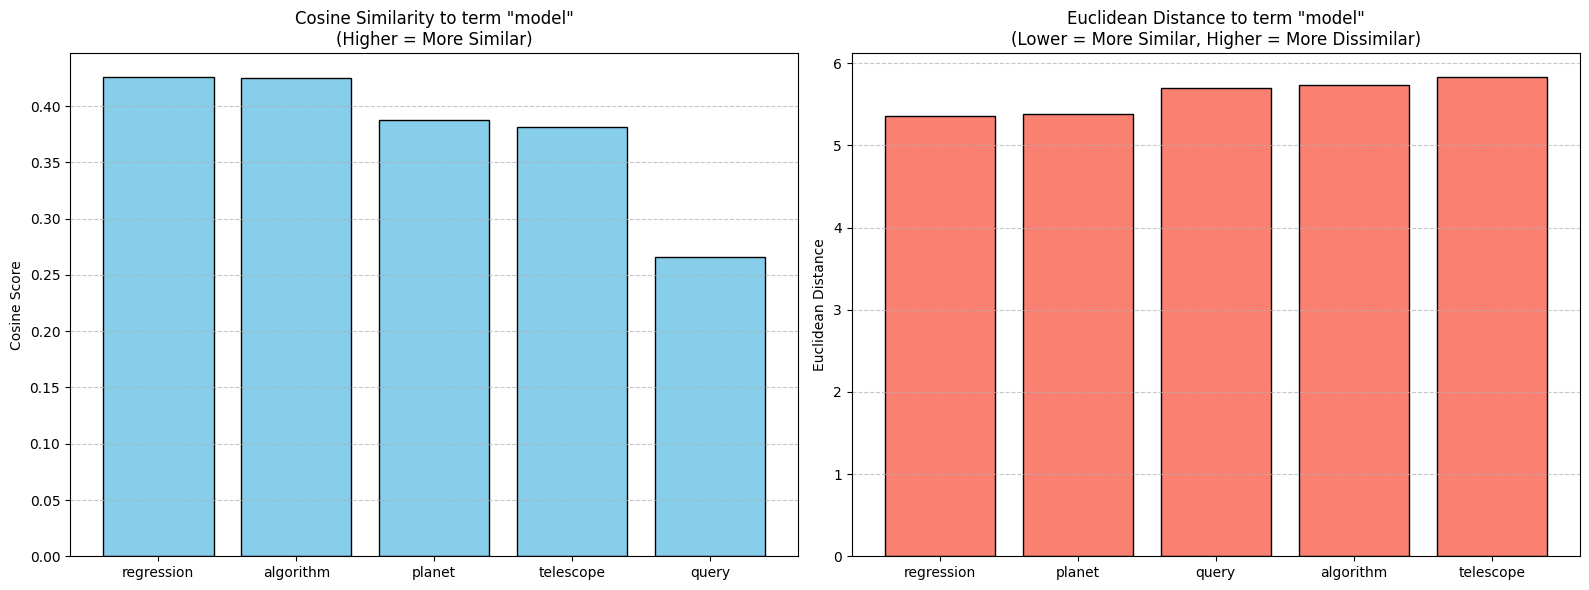

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.linalg import norm
from scipy.spatial.distance import euclidean

def calculate_relationship(vec1, vec2, metric='cosine'):
    """
    Computes the relationship between two vectors using the specified metric.
    Metrics: 'cosine' (similarity) or 'euclidean' (dissimilarity).
    """
    if metric == 'cosine':
        return np.dot(vec1, vec2) / (norm(vec1) * norm(vec2) + 1e-10)
    elif metric == 'euclidean':
        return euclidean(vec1, vec2)
    else:
        raise ValueError("Metric must be 'cosine' or 'euclidean'")

# Visualization 1: Ranking of Words
target_word = "model"
comparison_words = ["algorithm", "regression", "query", "planet", "telescope"]

# Fetch target vector
target_vec = get_word_embedding(target_word, embedding_model, vocab, False)

cosine_scores = []
euclidean_scores = []

for word in comparison_words:
    vec = get_word_embedding(word, embedding_model, vocab, False)

    cosine_scores.append(calculate_relationship(target_vec, vec, metric='cosine'))
    euclidean_scores.append(calculate_relationship(target_vec, vec, metric='euclidean'))

# Plot 1: Ranking Comparison (Bar Chart)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sort for Cosine descending
cos_sorted_indices = np.argsort(cosine_scores)[::-1]

axes[0].bar([comparison_words[i] for i in cos_sorted_indices],
            [cosine_scores[i] for i in cos_sorted_indices], color='skyblue', edgecolor='k')
axes[0].set_title(f'Cosine Similarity to term "{target_word}"\n(Higher = More Similar)')
axes[0].set_ylabel('Cosine Score')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Sort for Euclidean ascending
euc_sorted_indices = np.argsort(euclidean_scores)

axes[1].bar([comparison_words[i] for i in euc_sorted_indices],
            [euclidean_scores[i] for i in euc_sorted_indices], color='salmon', edgecolor='k')
axes[1].set_title(f'Euclidean Distance to term "{target_word}"\n(Lower = More Similar, Higher = More Dissimilar)')
axes[1].set_ylabel('Euclidean Distance')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

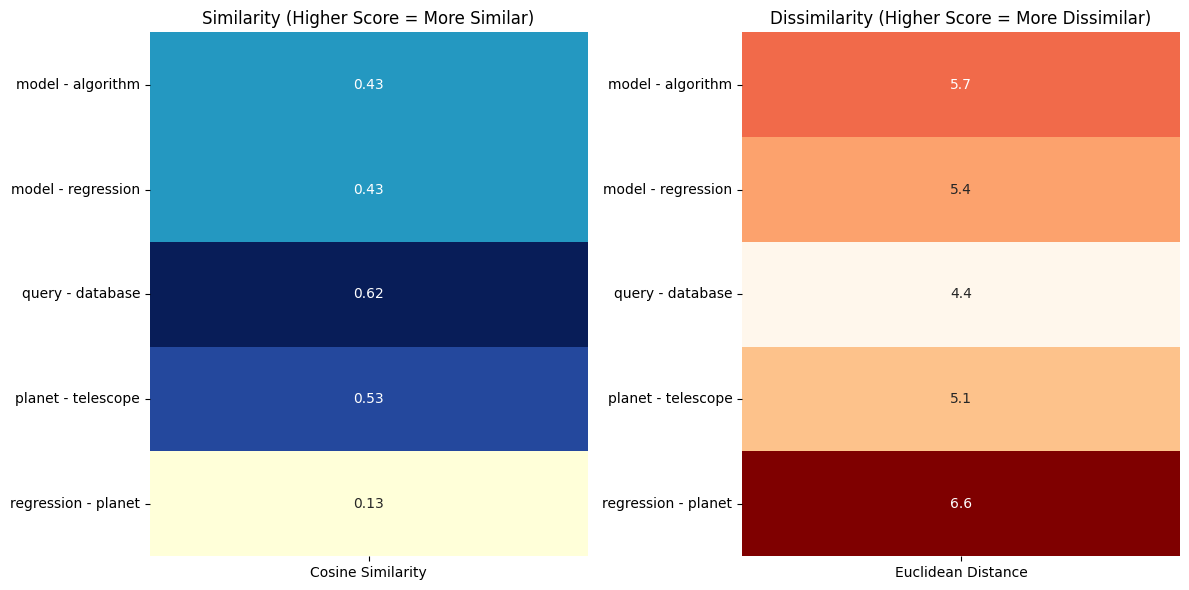

In [27]:
# Visualization 2: Heatmap
word_pairs = [
    ("model", "algorithm"),
    ("model", "regression"),
    ("query", "database"),
    ("planet", "telescope"),
    ("regression", "planet")
]

# Create matrices to hold the scores
heatmap_cosine = np.zeros((len(word_pairs), 1))
heatmap_euclidean = np.zeros((len(word_pairs), 1))
pair_labels = []

for i, (w1, w2) in enumerate(word_pairs):
    v1 = get_word_embedding(w1, embedding_model, vocab, False)
    v2 = get_word_embedding(w2, embedding_model, vocab, False)

    heatmap_cosine[i, 0] = calculate_relationship(v1, v2, metric='cosine')
    heatmap_euclidean[i, 0] = calculate_relationship(v1, v2, metric='euclidean')
    pair_labels.append(f"{w1} - {w2}")

# Plot 2: Side-by-Side Heatmaps
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.heatmap(heatmap_cosine, annot=True, cmap="YlGnBu", yticklabels=pair_labels, xticklabels=["Cosine Similarity"], ax=ax[0], cbar=False)
ax[0].set_title("Similarity (Higher Score = More Similar)")

sns.heatmap(heatmap_euclidean, annot=True, cmap="OrRd", yticklabels=pair_labels, xticklabels=["Euclidean Distance"], ax=ax[1], cbar=False)
ax[1].set_title("Dissimilarity (Higher Score = More Dissimilar)")

plt.tight_layout()
plt.show()

To evaluate the effectiveness of Euclidean distance as a novel dissimilarity metric, two visualizations were generated: a set of bar charts ranking candidate words against the target word "model," and side-by-side heatmaps comparing the relationships of specific word pairs. The heatmaps confirm that both metrics successfully identify strong semantic relationships while penalizing unrelated concepts. For instance, the highly related pair "query" and "database" achieved the highest cosine similarity (0.62) and correspondingly the lowest Euclidean distance (4.4). Conversely, the unrelated, cross-domain pair "regression" and "planet" correctly received the lowest similarity score (0.13) and the highest spatial distance penalty (6.6), visually proving that both mathematical approaches accurately map human conceptual boundaries.

However, the bar charts evaluating words relative to "model" reveal the crucial divergence between the two metrics and highlight the advantage of Euclidean distance for capturing novelty. Under cosine similarity, the terms "regression" and "algorithm" receive nearly identical scores (approximately 0.43), as their vectors point in roughly the same semantic direction. The Euclidean distance metric breaks this tie, ranking "regression" (with a distance of roughly 5.4) as closer to "model" than "algorithm" (which jumps to a distance of roughly 5.7). Since Euclidean distance accounts for vector magnitude, which strongly correlates with a word's frequency and conceptual breadth in the training corpus, it successfully distinguishes between the more ubiquitous term ("algorithm") and the more specific term ("regression"). By penalizing the magnitude differences that cosine similarity ignores, Euclidean distance proves to be an effective metric for identifying conceptual novelty within the embedding space.